In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #just used to not show warnings

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";", quotechar='"')
# df = df.iloc[:,0].str.split(";", expand=True)
# df.columns = [
# 'age','job','marital','education','default','balance','housing','loan',
# 'contact','day','month','duration','campaign','pdays','previous','poutcome','y'
# ]
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [5]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(15)

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [9]:
df.shape

(41199, 21)

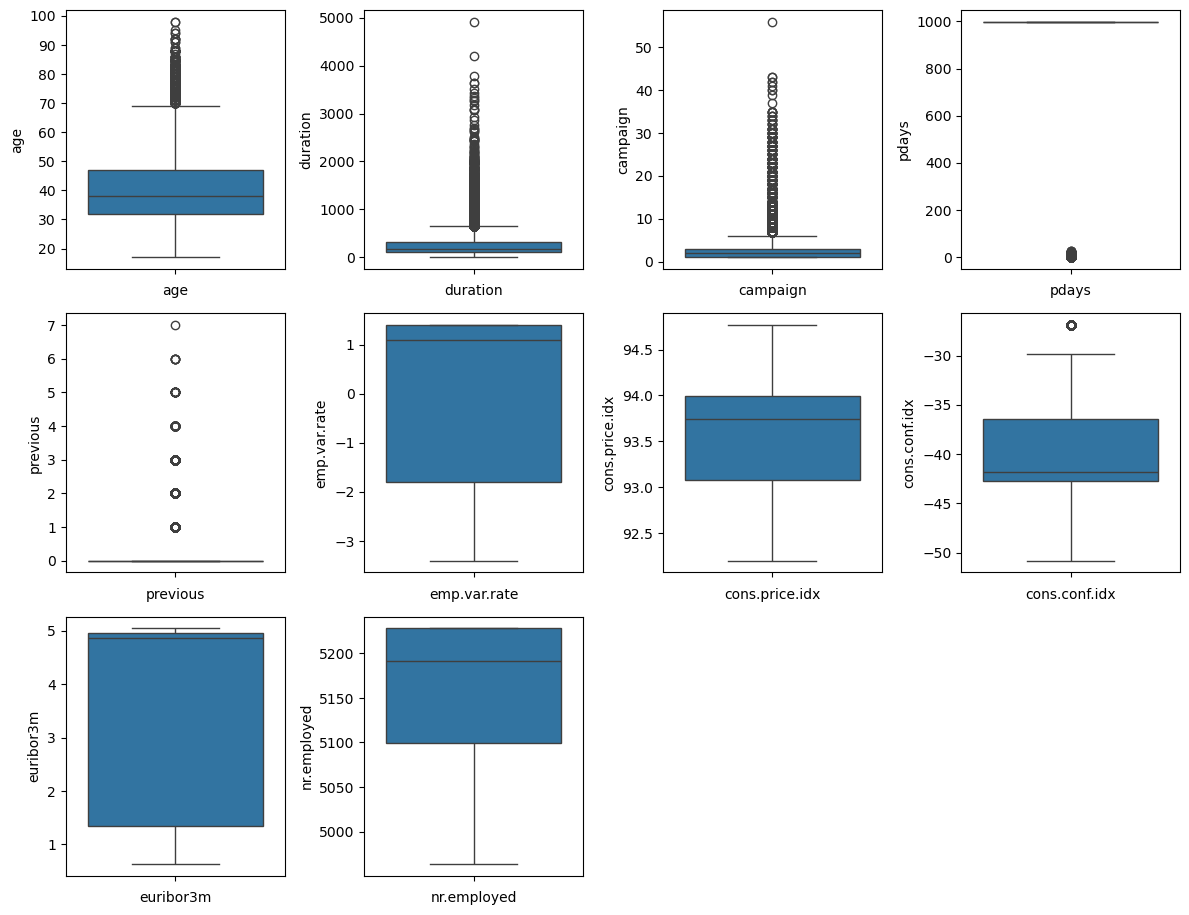

In [10]:
plt.figure(figsize=(12,12))
z=1
for i in df.columns:
    if (df[i].dtype == 'int64' or df[i].dtype == 'float64'):
        plt.subplot(4,4,z)
        sns.boxplot(df[i])
        plt.xlabel(i)
        z+=1
plt.tight_layout()
plt.show()

In [11]:
q1=df['age'].quantile(0.25)
q3=df['age'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr
df=df[(df['age']>=lower)&(df['age']<=upper)]

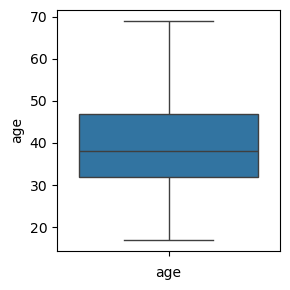

In [12]:
plt.figure(figsize=(3,3))
sns.boxplot(df['age'])
plt.xlabel('age')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()

In [15]:
for i in df.columns:
    if df[i].dtype == 'object':
        # print(df[i].value_counts())
        print(i)
        print(df[i].nunique())
        print(df[i].unique())
        print()

job
12
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

marital
4
['married' 'single' 'divorced' 'unknown']

education
8
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

default
3
['no' 'unknown' 'yes']

housing
3
['no' 'yes' 'unknown']

loan
3
['no' 'yes' 'unknown']

contact
2
['telephone' 'cellular']

month
10
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

day_of_week
5
['mon' 'tue' 'wed' 'thu' 'fri']

poutcome
3
['nonexistent' 'failure' 'success']

y
2
['no' 'yes']



In [16]:
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i]) # alphabetical order 

In [17]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41182,29.0,10,2,0,0,2,0,0,7,0,...,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6,0
41184,46.0,1,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,5,1,6,0,2,0,0,7,0,...,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0


** VIF - variance inflation factor **
* if two columns are giving out the same information and we want to find those columns we use it 
* it gives use the multi colinearity between the features 
* it gives the score based on past featues
* if multi colinearity is more than 5 drop the column

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [19]:
col_list = []
for col in df.columns:
    if((df[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)

In [20]:
X = df[col_list]
X

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,281.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29.0,10,2,0,0,2,0,0,7,0,112.0,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6


In [21]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,22.012231
1,job,2.102606
2,marital,5.697503
3,education,4.541597
4,default,1.414059
5,housing,2.204721
6,loan,1.207863
7,contact,2.895464
8,month,6.859000
9,day_of_week,3.085601


In [22]:
# when we have loats of columns we want to reduce the columns so that the machine would learn faster.
# so we use variance inflation factor , its one of the tequnices for reducing the no of columns.

In [23]:
X.shape[1]

20

In [24]:
X.drop(['nr.employed'],axis=1,inplace=True)

In [25]:
X.shape[1]

19

In [26]:
X.values

array([[ 56.   ,   3.   ,   1.   , ...,  93.994, -36.4  ,   4.857],
       [ 57.   ,   7.   ,   1.   , ...,  93.994, -36.4  ,   4.857],
       [ 37.   ,   7.   ,   1.   , ...,  93.994, -36.4  ,   4.857],
       ...,
       [ 46.   ,   1.   ,   1.   , ...,  94.767, -50.8  ,   1.028],
       [ 56.   ,   5.   ,   1.   , ...,  94.767, -50.8  ,   1.028],
       [ 44.   ,   9.   ,   1.   , ...,  94.767, -50.8  ,   1.028]])

In [27]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,22.005093
1,job,2.102483
2,marital,5.696788
3,education,4.540480
4,default,1.411565
5,housing,2.204152
6,loan,1.207806
7,contact,2.419050
8,month,5.885185
9,day_of_week,3.084992


In [28]:
X.drop(['pdays'],axis=1,inplace=True)

In [29]:
X.shape[1]

18

In [30]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,22.004408
1,job,2.102409
2,marital,5.696787
3,education,4.540371
4,default,1.411561
5,housing,2.203920
6,loan,1.207794
7,contact,2.418663
8,month,5.885082
9,day_of_week,3.084985


In [31]:
X.drop(['cons.price.idx'],axis=1,inplace=True)

In [32]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,19.990190
1,job,2.093479
2,marital,5.427138
3,education,4.439071
4,default,1.411493
5,housing,2.199868
6,loan,1.207280
7,contact,2.274365
8,month,5.802007
9,day_of_week,3.059424


In [33]:
X.drop(['euribor3m'],axis=1,inplace=True)

In [34]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range( X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,16.694422
1,job,2.085946
2,marital,5.192877
3,education,4.274426
4,default,1.411057
5,housing,2.191647
6,loan,1.206930
7,contact,2.267899
8,month,5.291869
9,day_of_week,3.018499


In [35]:
X.drop(['cons.conf.idx'],axis = 1,inplace = True)

In [36]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range( X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,age,10.481090
1,job,2.078069
2,marital,4.300602
3,education,4.169888
4,default,1.410059
5,housing,2.154981
6,loan,1.203141
7,contact,2.247348
8,month,4.956417
9,day_of_week,2.958154


In [37]:
X.drop(['age'],axis=1,inplace=True)

In [38]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range( X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,job,2.051147
1,marital,4.292362
2,education,3.959743
3,default,1.320358
4,housing,2.099662
5,loan,1.199411
6,contact,2.246427
7,month,4.622838
8,day_of_week,2.861824
9,duration,1.936513


In [39]:
X.drop(['poutcome'],axis = 1,inplace = True)

In [40]:
vif_data = pd.DataFrame()
vif_data['Col_Name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data

,Col_Name,VIF_Score
0,job,2.025740
1,marital,4.015675
2,education,3.677662
3,default,1.306395
4,housing,2.057648
5,loan,1.196727
6,contact,2.231704
7,month,4.428765
8,day_of_week,2.752800
9,duration,1.878769


In [41]:
for i,j in zip(vif_data['Col_Name'],vif_data['VIF_Score']):
    print(f'{i} : {j}')

job : 2.0257403732491093
marital : 4.0156748350622955
education : 3.6776621328383556
default : 1.3063946030604916
housing : 2.057647690249627
loan : 1.196727022300073
contact : 2.231704328411119
month : 4.428764544808416
day_of_week : 2.752799593787843
duration : 1.8787685901606785
campaign : 1.7942694149258933
previous : 1.366907108994474
emp.var.rate : 1.5587168682760906


# RFE - (Recursive Feature Elimination)
* Recursive Feature Elimination (RFE) is a method that recursively removes the least important features from the dataset and builds the model again until the desired number of features is reached
* Recursive Feature Elimination (RFE) is a feature selection technique used in Machine Learning to select the most important features (variables) for building a model.

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
model = LogisticRegression()

In [44]:
from sklearn.feature_selection import RFE

In [45]:
rfe = RFE(model)

In [46]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [47]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37.0,0,1,6,0,2,0,0,7,0,281.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29.0,10,2,0,0,2,0,0,7,0,112.0,1.0,9.0,1.0,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6


In [48]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41181    1
41182    0
41184    0
41185    0
41186    1
Name: y, Length: 40719, dtype: int64

In [49]:
rfe.fit(x,y)

RFE(estimator=LogisticRegression())

In [50]:
rfe.support_
#the above line tells how many features are selected

array([False, False,  True,  True,  True, False, False,  True, False,
        True, False,  True, False,  True,  True,  True, False, False,
        True, False])

In [51]:
rfe.ranking_
# 1 - important fatutre 
# grater number less importent feature

array([11,  8,  1,  1,  1,  4,  5,  1,  3,  1,  9,  1, 10,  1,  1,  1,  6,
        2,  1,  7])

In [52]:
for i,j in zip(x.columns,rfe.support_):
    print(f'{i} : {j}')

age : False
job : False
marital : True
education : True
default : True
housing : False
loan : False
contact : True
month : False
day_of_week : True
duration : False
campaign : True
pdays : False
previous : True
poutcome : True
emp.var.rate : True
cons.price.idx : False
cons.conf.idx : False
euribor3m : True
nr.employed : False


In [53]:
for i,data in enumerate(rfe.support_):
    print(f'{i} : {data}')

0 : False
1 : False
2 : True
3 : True
4 : True
5 : False
6 : False
7 : True
8 : False
9 : True
10 : False
11 : True
12 : False
13 : True
14 : True
15 : True
16 : False
17 : False
18 : True
19 : False


In [54]:
selected_indexes = [i for i,data in enumerate(rfe.support_) if data==True]
selected_indexes

[2, 3, 4, 7, 9, 11, 13, 14, 15, 18]

In [55]:
column_names = x.columns
column_names

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [56]:
selected_columns = [column_names[i] for i in selected_indexes]
selected_columns

['marital',
 'education',
 'default',
 'contact',
 'day_of_week',
 'campaign',
 'previous',
 'poutcome',
 'emp.var.rate',
 'euribor3m']

In [57]:
x = x.loc[:,selected_columns]
x

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,emp.var.rate,euribor3m
0,1,0,0,1,1,1.0,0.0,1,1.1,4.857
1,1,3,1,1,1,1.0,0.0,1,1.1,4.857
2,1,3,0,1,1,1.0,0.0,1,1.1,4.857
3,1,1,0,1,1,1.0,0.0,1,1.1,4.857
4,1,3,0,1,1,1.0,0.0,1,1.1,4.857
...,...,...,...,...,...,...,...,...,...,...
41181,1,6,0,0,0,1.0,0.0,1,-1.1,1.028
41182,2,0,0,0,0,1.0,1.0,2,-1.1,1.028
41184,1,5,0,0,0,1.0,0.0,1,-1.1,1.028
41185,1,6,0,0,0,2.0,0.0,1,-1.1,1.028


In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=1)

In [60]:
x_train

,marital,education,default,contact,day_of_week,campaign,previous,poutcome,emp.var.rate,euribor3m
9795,1,0,1,1,4,3.0,0.0,1,1.4,4.959
35110,2,5,0,0,0,5.0,0.0,1,-1.8,1.250
30220,2,6,0,0,2,2.0,0.0,1,-1.8,1.365
7275,1,1,0,1,2,2.0,0.0,1,1.1,4.860
20794,1,2,1,1,4,2.0,0.0,1,1.4,4.965
...,...,...,...,...,...,...,...,...,...,...
7813,1,6,1,1,1,1.0,0.0,1,1.4,4.865
32582,1,2,0,0,1,1.0,2.0,0,-1.8,1.299
5192,1,2,0,1,0,1.0,0.0,1,1.1,4.857
12172,1,3,0,1,3,1.0,0.0,1,1.4,4.955


In [61]:
y_train

9795     0
35110    0
30220    1
7275     0
20794    0
        ..
7813     0
32582    0
5192     0
12172    0
33074    0
Name: y, Length: 32575, dtype: int64

In [62]:
lr = LogisticRegression()

In [63]:
lr.fit(x_train,y_train)

LogisticRegression()

In [64]:
y_predict = lr.predict(x_test)
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [65]:
act_pred = pd.DataFrame()

In [66]:
act_pred['actual'] = y_test
act_pred['predicted'] = y_predict
act_pred

,actual,predicted
15585,0,0
5458,0,0
35490,0,0
24776,0,0
32591,0,0
...,...,...
3448,0,0
20583,0,0
26123,0,0
26245,0,0


In [67]:
from sklearn.metrics import *

In [68]:
accuracy_score(y_test,y_predict)*100

89.9680746561886

In [69]:
# for practice we an also perform logestic regression on titanic dataset . Wether they are dead or alive 
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
